<div style="
    background: linear-gradient(90deg, #0F172A, #1E3A8A);
    color: white;
    padding: 22px;
    border-radius: 14px;
    text-align: center;
    font-family: Arial;
">
    <h1>Telecom Customer Churn Analysis</h1>
    <h3>Data Cleaning, Data Modeling & Visualization</h3>
</div>

In [1]:
# ============================================================
# 1) Libraries & Global Settings
# ============================================================

import os
import sqlite3
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")
%matplotlib inline
BASE_DIR = os.getcwd()

print("Libraries imported successfully.")

Libraries imported successfully.


<div style="
    background: linear-gradient(90deg, #334155, #64748B);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">File Conversion</h2>
    <p style="margin: 6px 0 0 0;">Convert Excel file to CSV format if needed.</p>
</div>

In [2]:
file = "telecom_customer_churn.csv.xlsx"

df = pd.read_excel(file)

df.to_csv("telecom_customer_churn.csv", index=False)

print("Converted successfully!")

Converted successfully!


<div style="
    background: linear-gradient(90deg, #064E3B, #0F766E);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Data Loading</h2>
    <p style="margin: 6px 0 0 0;">Load churn and telecom customer datasets.</p>
</div>

In [3]:
df1 = pd.read_csv("Churn.csv")
df2 = pd.read_csv("telecom_customer_churn.csv")

print("Churn dataset shape:", df1.shape)
print("Telecom customer dataset shape:", df2.shape)

display(df1.head())
display(df2.head())

Churn dataset shape: (7043, 21)
Telecom customer dataset shape: (7043, 38)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.83,-119.00,2,9,NaN,Yes,42.39,No,Yes,Cable,16.00,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.60,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.16,-118.20,0,9,NaN,Yes,10.69,Yes,Yes,Cable,10.00,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.00,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.65,-117.92,0,4,Offer E,Yes,33.65,No,Yes,Fiber Optic,30.00,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.90,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.01,-122.12,1,13,Offer D,Yes,27.82,No,Yes,Fiber Optic,4.00,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.00,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.23,-119.08,3,3,NaN,Yes,7.38,No,Yes,Fiber Optic,11.00,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,83.90,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


<div style="
    background: linear-gradient(90deg, #1E3A8A, #2563EB);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Initial Exploration - Churn Dataset</h2>
    <p style="margin: 6px 0 0 0;">Check data information, missing values, and descriptive statistics.</p>
</div>

In [4]:
print("Churn Dataset Info")
df1.info()

print("\nMissing Values in Churn Dataset")
display(
    df1.isnull()
    .sum()
    .reset_index()
    .rename(columns={"index": "Column", 0: "Missing Values"})
)

print("\nDescriptive Statistics for Churn Dataset")
display(df1.describe(include="all").T)

Churn Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 

,Column,Missing Values
0,customerID,0
1,gender,0
2,SeniorCitizen,0
3,Partner,0
4,Dependents,0
5,tenure,0
6,PhoneService,0
7,MultipleLines,0
8,InternetService,0
9,OnlineSecurity,0



Descriptive Statistics for Churn Dataset


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.00,NaN,NaN,NaN,0.16,0.37,0.00,0.00,0.00,0.00,1.00
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.00,NaN,NaN,NaN,32.37,24.56,0.00,9.00,29.00,55.00,72.00
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<div style="
    background: linear-gradient(90deg, #7C2D12, #C2410C);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Data Cleaning - Churn Table</h2>
    <p style="margin: 6px 0 0 0;">Clean and standardize the churn dataset.</p>
</div>

In [5]:
# Step 2: Clean Table 1 - Churn

churn = pd.DataFrame()

str_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

churn['customer_id'] = df1['customerID'].str.strip()
churn['SeniorCitizen']= df1['SeniorCitizen'].astype(int)
churn['tenure'] = df1['tenure'].astype(int)

for col in str_cols:
    churn[col] = df1[col].str.strip()

churn['monthly_charges'] = df1['MonthlyCharges'].astype(float).round(2)
churn['total_charges'] = (churn['monthly_charges'] * churn['tenure']).round(2)
churn['churn'] = df1['Churn'].str.strip()

churn.head()

,customer_id,SeniorCitizen,tenure,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,monthly_charges,total_charges,churn
0,7590-VHVEG,0,1,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,0,34,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1936.30,No
2,3668-QPYBK,0,2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,107.70,Yes
3,7795-CFOCW,0,45,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1903.50,No
4,9237-HQITU,0,2,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,141.40,Yes


<div style="
    background: linear-gradient(90deg, #1E40AF, #3B82F6);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Initial Exploration - Telecom Customer Dataset</h2>
    <p style="margin: 6px 0 0 0;">Check data information, missing values, and descriptive statistics.</p>
</div>

In [6]:
print("Telecom Customer Dataset Info")
df2.info()

print("\nMissing Values in Telecom Customer Dataset")
display(
    df2.isnull()
    .sum()
    .reset_index()
    .rename(columns={"index": "Column", 0: "Missing Values"})
)

print("\nDescriptive Statistics for Telecom Customer Dataset")
display(df2.describe(include="all").T)

Telecom Customer Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                     

,Column,Missing Values
0,Customer ID,0
1,Gender,0
2,Age,0
3,Married,0
4,Number of Dependents,0
5,City,0
6,Zip Code,0
7,Latitude,0
8,Longitude,0
9,Number of Referrals,0



Descriptive Statistics for Telecom Customer Dataset


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,7043,7043,9995-HOTOH,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,7043.00,NaN,NaN,NaN,46.51,16.75,19.00,32.00,46.00,60.00,80.00
Married,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of Dependents,7043.00,NaN,NaN,NaN,0.47,0.96,0.00,0.00,0.00,0.00,9.00
City,7043,1106,Los Angeles,293,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.00,NaN,NaN,NaN,93486.07,1856.77,90001.00,92101.00,93518.00,95329.00,96150.00
Latitude,7043.00,NaN,NaN,NaN,36.20,2.47,32.56,33.99,36.21,38.16,41.96
Longitude,7043.00,NaN,NaN,NaN,-119.76,2.15,-124.30,-121.79,-119.60,-117.97,-114.19
Number of Referrals,7043.00,NaN,NaN,NaN,1.95,3.00,0.00,0.00,0.00,3.00,11.00


<div style="
    background: linear-gradient(90deg, #92400E, #F97316);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Data Cleaning - Telecom Customer Table</h2>
    <p style="margin: 6px 0 0 0;">Clean customer, location, service, contract, payment, and churn columns.</p>
</div>

In [7]:
# Step 3: Clean Table 2 - telecom_customer_churn
telecom = pd.DataFrame()

no_phone = df2['Phone Service'].str.strip() == 'No'
no_internet = df2['Internet Service'].str.strip() == 'No'
stayed = df2['Customer Status'].str.strip().isin(['Stayed', 'Joined'])

# Customers 
telecom['customer_id'] = df2['Customer ID'].str.strip()
telecom['gender'] = df2['Gender'].str.strip()
telecom['Age'] = df2['Age'].astype(int)
telecom['Married'] = df2['Married'].str.strip()
telecom['Number_of_Dependents'] = df2['Number of Dependents'].astype(int)

# Location 
telecom['City']   = df2['City'].str.strip()
telecom['Zip_Code'] = df2['Zip Code'].astype(int)
telecom['Latitude'] = df2['Latitude'].astype(float)
telecom['Longitude']= df2['Longitude'].astype(float)

# Subscription 
telecom['Number_of_Referrals'] = df2['Number of Referrals'].astype(int)
telecom['tenure'] = df2['Tenure in Months'].astype(int)
telecom['Offer'] = df2['Offer'].str.strip()
telecom['Offer'] = telecom['Offer'].fillna('None')  

# Phone Service 
telecom['Phone_Service'] = df2['Phone Service'].str.strip()

telecom['Avg_Monthly_Long_Distance_Charges'] = np.where(
    no_phone, 0,
    pd.to_numeric(df2['Avg Monthly Long Distance Charges'], errors='coerce').round(2)
)
telecom['Multiple_Lines'] = np.where(no_phone, 'No phone service', df2['Multiple Lines'].str.strip())

# Internet Service 
telecom['Internet_Service'] = df2['Internet Service'].str.strip()
telecom['Internet_Type'] = np.where(no_internet, 'No internet', df2['Internet Type'].str.strip())

telecom['Avg_Monthly_GB_Download'] = np.where(
    no_internet | (df2['Internet Type'].str.strip() == 'No internet'), 0,
    pd.to_numeric(df2['Avg Monthly GB Download'], errors='coerce')
)

# Internet-Dependent Services 
internet_cols = {
    'Online_Security' :'Online Security',
    'Online_Backup':'Online Backup',
    'Device_Protection':'Device Protection Plan',
    'Premium_Tech_Support':'Premium Tech Support',
    'Streaming_TV': 'Streaming TV',
    'Streaming_Movies':'Streaming Movies',
    'Streaming_Music':'Streaming Music',
    'Unlimited_Data':'Unlimited Data',
}
for new_col, old_col in internet_cols.items():
    telecom[new_col] = np.where(no_internet, 'No internet service', df2[old_col].str.strip())

# Contract & Payment 
telecom['Contract'] = df2['Contract'].str.strip()
telecom['Paperless_Billing'] = df2['Paperless Billing'].str.strip()
telecom['Payment_Method'] = df2['Payment Method'].str.strip()

# Charges 
charge_cols = {
    'monthly_charges':'Monthly Charge',
    'total_charges':'Total Charges',
    'Total_Refunds':'Total Refunds',
    'Total_Extra_Data_Charges':'Total Extra Data Charges',
    'Total_Long_Distance_Charges':'Total Long Distance Charges',
    'Total_Revenue':'Total Revenue',
}
for new_col, old_col in charge_cols.items():
    telecom[new_col] = df2[old_col].astype(float).round(2)

# Churn 
def clean_churn_col(col):
    values = col.astype(str).str.strip()
    return np.where(stayed, 'No churn', np.where(values.isin(['', 'nan']), 'Unknown', values))

telecom['churn'] = np.where(stayed, 'No', 'Yes')
telecom['Churn_Category'] = clean_churn_col(df2['Churn Category'])
telecom['Churn_Reason'] = clean_churn_col(df2['Churn Reason'])

display(telecom.iloc[20:27])

,customer_id,gender,Age,Married,Number_of_Dependents,City,Zip_Code,Latitude,Longitude,Number_of_Referrals,tenure,Offer,Phone_Service,Avg_Monthly_Long_Distance_Charges,Multiple_Lines,Internet_Service,Internet_Type,Avg_Monthly_GB_Download,Online_Security,Online_Backup,Device_Protection,Premium_Tech_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,monthly_charges,total_charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,churn,Churn_Category,Churn_Reason
20,0023-UYUPN,Female,79,Yes,0,Ahwahnee,93601,37.38,-119.74,0,50,None,Yes,31.43,Yes,No,No internet,0.00,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One Year,No,Bank Withdrawal,25.20,1306.30,0.00,0.00,1571.50,2877.80,No,No churn,No churn
21,0023-XUOPT,Female,26,Yes,0,Carnelian Bay,96140,39.23,-120.09,1,13,None,Yes,43.56,Yes,Yes,Fiber Optic,52.00,No,Yes,Yes,No,Yes,No,No,Yes,Month-to-Month,No,Bank Withdrawal,94.10,1215.60,0.00,0.00,566.28,1781.88,Yes,Other,Don't know
22,0027-KWYKW,Female,30,Yes,2,Alpaugh,93201,35.87,-119.50,1,23,Offer D,Yes,34.91,Yes,Yes,Fiber Optic,30.00,No,No,No,No,Yes,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,83.75,1849.95,0.00,0.00,802.93,2652.88,No,No churn,No churn
23,0030-FNXPP,Female,22,No,0,Keeler,93530,36.56,-117.96,0,3,None,Yes,3.12,No,No,No internet,0.00,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-Month,No,Credit Card,19.85,57.20,0.00,0.00,9.36,66.56,No,No churn,No churn
24,0031-PVLZI,Female,34,Yes,0,Korbel,95550,40.77,-123.80,0,4,Offer E,Yes,12.43,No,No,No internet,0.00,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-Month,No,Credit Card,20.35,76.35,0.00,0.00,49.72,126.07,Yes,Price,Long distance charges
25,0032-PGELS,Female,37,Yes,1,Palomar Mountain,92060,33.31,-116.82,1,1,None,No,0.00,No phone service,Yes,DSL,19.00,Yes,No,No,No,No,No,No,Yes,Month-to-Month,No,Bank Withdrawal,30.50,30.50,0.00,0.00,0.00,30.50,Yes,Attitude,Attitude of service provider
26,0036-IHMOT,Female,37,Yes,3,Parlier,93648,36.62,-119.52,10,55,None,Yes,35.04,No,Yes,Fiber Optic,57.00,No,Yes,Yes,Yes,Yes,Yes,Yes,No,One Year,Yes,Bank Withdrawal,103.70,5656.75,0.00,20.00,1927.20,7603.95,No,No churn,No churn


<div style="
    background: linear-gradient(90deg, #065F46, #10B981);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Merge Cleaned Data</h2>
    <p style="margin: 6px 0 0 0;">Merge churn data with telecom customer data and prepare the final dataset.</p>
</div>

In [8]:
# Step 4: Merge  

churn_subset = churn[['customer_id', 'monthly_charges', 'SeniorCitizen']].copy()
churn_subset = churn_subset.rename(columns={'monthly_charges': 'monthly_charges_churn'})
 
merged = telecom.merge(churn_subset, on='customer_id', how='left', suffixes=('', '_churn'))
 
merged['monthly_charges'] = merged['monthly_charges_churn']
merged.drop(columns=['monthly_charges_churn'], inplace=True)
 
merged['total_charges'] = (merged['monthly_charges'] * merged['tenure']).round(2)
 
merged['Total_Revenue'] = (
    merged['total_charges'] +
    merged['Total_Extra_Data_Charges'] +
    merged['Total_Long_Distance_Charges'] -
    merged['Total_Refunds']
).round(2)

def get_tenure_group(tenure):
    if   0  <= tenure <= 12: return '0-12 months'
    elif 13 <= tenure <= 24: return '13-24 months'
    elif 25 <= tenure <= 48: return '25-48 months'
    elif 49 <= tenure <= 72: return '49-72 months'
    else:                    return 'Unknown'
 
merged['Tenure_Group'] = merged['tenure'].apply(get_tenure_group)
# Age Group
merged['Age_Group'] = pd.cut(
    merged['Age'],
    bins=[0, 30, 45, 60, 120],
    labels=['18-30', '31-45', '46-60', '60+']
).astype(str)

# Senior Label
merged['Senior_Label'] = merged['SeniorCitizen']\
    .map({1: 'Senior', 0: 'Non-Senior'})
 # Rename Married values
merged['Married'] = merged['Married'].map({'Yes': 'Married', 'No': 'Not Married'})

display(merged.iloc[20:26])

,customer_id,gender,Age,Married,Number_of_Dependents,City,Zip_Code,Latitude,Longitude,Number_of_Referrals,tenure,Offer,Phone_Service,Avg_Monthly_Long_Distance_Charges,Multiple_Lines,Internet_Service,Internet_Type,Avg_Monthly_GB_Download,Online_Security,Online_Backup,Device_Protection,Premium_Tech_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,monthly_charges,total_charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,churn,Churn_Category,Churn_Reason,SeniorCitizen,Tenure_Group,Age_Group,Senior_Label
20,0023-UYUPN,Female,79,Married,0,Ahwahnee,93601,37.38,-119.74,0,50,None,Yes,31.43,Yes,No,No internet,0.00,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One Year,No,Bank Withdrawal,25.20,1260.00,0.00,0.00,1571.50,2831.50,No,No churn,No churn,1,49-72 months,60+,Senior
21,0023-XUOPT,Female,26,Married,0,Carnelian Bay,96140,39.23,-120.09,1,13,None,Yes,43.56,Yes,Yes,Fiber Optic,52.00,No,Yes,Yes,No,Yes,No,No,Yes,Month-to-Month,No,Bank Withdrawal,94.10,1223.30,0.00,0.00,566.28,1789.58,Yes,Other,Don't know,0,13-24 months,18-30,Non-Senior
22,0027-KWYKW,Female,30,Married,2,Alpaugh,93201,35.87,-119.50,1,23,Offer D,Yes,34.91,Yes,Yes,Fiber Optic,30.00,No,No,No,No,Yes,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,83.75,1926.25,0.00,0.00,802.93,2729.18,No,No churn,No churn,0,13-24 months,18-30,Non-Senior
23,0030-FNXPP,Female,22,Not Married,0,Keeler,93530,36.56,-117.96,0,3,None,Yes,3.12,No,No,No internet,0.00,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-Month,No,Credit Card,19.85,59.55,0.00,0.00,9.36,68.91,No,No churn,No churn,0,0-12 months,18-30,Non-Senior
24,0031-PVLZI,Female,34,Married,0,Korbel,95550,40.77,-123.80,0,4,Offer E,Yes,12.43,No,No,No internet,0.00,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-Month,No,Credit Card,20.35,81.40,0.00,0.00,49.72,131.12,Yes,Price,Long distance charges,0,0-12 months,31-45,Non-Senior
25,0032-PGELS,Female,37,Married,1,Palomar Mountain,92060,33.31,-116.82,1,1,None,No,0.00,No phone service,Yes,DSL,19.00,Yes,No,No,No,No,No,No,Yes,Month-to-Month,No,Bank Withdrawal,30.50,30.50,0.00,0.00,0.00,30.50,Yes,Attitude,Attitude of service provider,0,0-12 months,31-45,Non-Senior


<div style="
    background: linear-gradient(90deg, #075985, #0EA5E9);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Save Cleaned Files</h2>
    <p style="margin: 6px 0 0 0;">Export cleaned and merged datasets to Excel files.</p>
</div>

In [9]:
# Save Files
telecom_customer_churn = telecom.copy()
telecom_merged = merged.copy()

churn.to_excel("Churn.xlsx", index=False)
telecom_customer_churn.to_excel("telecom_customer_churn.xlsx", index=False)
telecom_merged.to_excel("telecom_merged.xlsx",index=False)  

<div style="
    background: linear-gradient(90deg, #312E81, #7E22CE);
    color: white;
    padding: 20px;
    border-radius: 14px;
    text-align: center;
    font-family: Arial;
    margin: 18px 0;
">
    <h1 style="margin: 0;">Data Modeling</h1>
    <p style="margin: 8px 0 0 0;">Star Schema Design using SQLite Database</p>
</div>

<div style="
    background: linear-gradient(90deg, #4C1D95, #7C3AED);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Database Connection</h2>
    <p style="margin: 6px 0 0 0;">Create SQLite database and load the merged dataset.</p>
</div>

In [10]:
# Load merged data
merged = pd.read_excel(os.path.join(BASE_DIR, "telecom_merged.xlsx"))

# Create SQLite database
conn = sqlite3.connect(os.path.join(BASE_DIR, "telecom_churn.db"))
cursor = conn.cursor()

# Enable Foreign Keys
cursor.execute("PRAGMA foreign_keys = ON")

print("Database created and connected successfully!")
print(f"Merged data loaded: {merged.shape[0]:,} rows × {merged.shape[1]} cols")

Database created and connected successfully!
Merged data loaded: 7,043 rows × 42 cols


<div style="
    background: linear-gradient(90deg, #3730A3, #6366F1);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Dimension Tables</h2>
    <p style="margin: 6px 0 0 0;">Create city, contract, services, churn, and customer dimension tables.</p>
</div>

In [11]:
# Dim_City
dim_city = merged[['City', 'Zip_Code', 'Latitude', 'Longitude']]\
    .drop_duplicates().reset_index(drop=True)
dim_city.insert(0, 'City_Key', range(1, len(dim_city) + 1))

# Dim_Contract
dim_contract = merged[['Contract', 'Payment_Method', 'Paperless_Billing', 'Offer']]\
    .drop_duplicates().reset_index(drop=True)
dim_contract.insert(0, 'Contract_Key', range(1, len(dim_contract) + 1))

# Dim_Services
service_cols = [
    'Phone_Service', 'Internet_Service', 'Multiple_Lines', 'Internet_Type',
    'Online_Security', 'Online_Backup', 'Device_Protection',
    'Premium_Tech_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data'
]
dim_services = merged[service_cols]\
    .drop_duplicates().reset_index(drop=True)
dim_services.insert(0, 'Services_Key', range(1, len(dim_services) + 1))

# Dim_Churn
dim_churn = merged[['Churn_Category', 'Churn_Reason']]\
    .drop_duplicates().reset_index(drop=True)
dim_churn.insert(0, 'Churn_Key', range(1, len(dim_churn) + 1))

# Dim_Customer
dim_customer = merged[[
    'customer_id', 'gender', 'SeniorCitizen',
    'Age', 'Married', 'Number_of_Dependents'
]].drop_duplicates(subset='customer_id').reset_index(drop=True)

print("All Dimension Tables built:")
print(f"  Dim_City:      {len(dim_city):,} rows")
print(f"  Dim_Contract:  {len(dim_contract):,} rows")
print(f"  Dim_Services:  {len(dim_services):,} rows")
print(f"  Dim_Churn:     {len(dim_churn):,} rows")
print(f"  Dim_Customer:  {len(dim_customer):,} rows")

All Dimension Tables built:
  Dim_City:      1,626 rows
  Dim_Contract:  104 rows
  Dim_Services:  966 rows
  Dim_Churn:     21 rows
  Dim_Customer:  7,043 rows


<div style="
    background: linear-gradient(90deg, #581C87, #A855F7);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Create Database Tables</h2>
    <p style="margin: 6px 0 0 0;">Create dimension and fact tables using SQL.</p>
</div>

In [12]:
# ── CREATE TABLES ──────────────────────────────────────

cursor.executescript("""

CREATE TABLE IF NOT EXISTS Dim_City (
    City_Key        INTEGER PRIMARY KEY,
    City            TEXT,
    Zip_Code        INTEGER,
    Latitude        REAL,
    Longitude       REAL
);

CREATE TABLE IF NOT EXISTS Dim_Contract (
    Contract_Key      INTEGER PRIMARY KEY,
    Contract          TEXT,
    Payment_Method    TEXT,
    Paperless_Billing TEXT,
    Offer             TEXT
);

CREATE TABLE IF NOT EXISTS Dim_Services (
    Services_Key         INTEGER PRIMARY KEY,
    Phone_Service        TEXT,
    Internet_Service     TEXT,
    Multiple_Lines       TEXT,
    Internet_Type        TEXT,
    Online_Security      TEXT,
    Online_Backup        TEXT,
    Device_Protection    TEXT,
    Premium_Tech_Support TEXT,
    Streaming_TV         TEXT,
    Streaming_Movies     TEXT,
    Streaming_Music      TEXT,
    Unlimited_Data       TEXT
);

CREATE TABLE IF NOT EXISTS Dim_Churn (
    Churn_Key      INTEGER PRIMARY KEY,
    Churn_Category TEXT,
    Churn_Reason   TEXT
);

CREATE TABLE IF NOT EXISTS Dim_Customer (
    customer_id          TEXT PRIMARY KEY,
    gender               TEXT,
    SeniorCitizen        TEXT,
    Age                  INTEGER,
    Married              TEXT,
    Number_of_Dependents INTEGER
);

CREATE TABLE IF NOT EXISTS Fact_Telecom_Company (
    customer_id                      TEXT PRIMARY KEY,
    City_Key                         INTEGER,
    Contract_Key                     INTEGER,
    Services_Key                     INTEGER,
    Churn_Key                        INTEGER,
    tenure                           INTEGER,
    Tenure_Group                     TEXT,
    Age_Group                        TEXT,
    monthly_charges                  REAL,
    total_charges                    REAL,
    Total_Revenue                    REAL,
    Avg_Monthly_Long_Distance_Charges REAL,
    Avg_Monthly_GB_Download          REAL,
    Total_Extra_Data_Charges         REAL,
    Total_Long_Distance_Charges      REAL,
    Total_Refunds                    REAL,
    Number_of_Referrals              INTEGER,
    churn                            TEXT,
    FOREIGN KEY (City_Key)     REFERENCES Dim_City(City_Key),
    FOREIGN KEY (Contract_Key) REFERENCES Dim_Contract(Contract_Key),
    FOREIGN KEY (Services_Key) REFERENCES Dim_Services(Services_Key),
    FOREIGN KEY (Churn_Key)    REFERENCES Dim_Churn(Churn_Key),
    FOREIGN KEY (customer_id)  REFERENCES Dim_Customer(customer_id)
);

""")

conn.commit()
print("All tables created successfully in SQLite!")

All tables created successfully in SQLite!


In [13]:
# ── Reset Tables ───────────────────────────────────────
cursor.executescript("""
    DROP TABLE IF EXISTS Fact_Telecom_Company;
    DROP TABLE IF EXISTS Dim_City;
    DROP TABLE IF EXISTS Dim_Contract;
    DROP TABLE IF EXISTS Dim_Services;
    DROP TABLE IF EXISTS Dim_Churn;
    DROP TABLE IF EXISTS Dim_Customer;
""")
conn.commit()
print("All tables dropped. Ready to recreate.")

All tables dropped. Ready to recreate.


In [14]:
# ── INSERT Dimension Data ──────────────────────────────

dim_city.to_sql('Dim_City', conn, if_exists='replace', index=False)
dim_contract.to_sql('Dim_Contract', conn, if_exists='replace', index=False)
dim_services.to_sql('Dim_Services', conn, if_exists='replace', index=False)
dim_churn.to_sql('Dim_Churn', conn, if_exists='replace', index=False)
dim_customer.to_sql('Dim_Customer', conn, if_exists='replace', index=False)

7043

<div style="
    background: linear-gradient(90deg, #9D174D, #EC4899);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Fact Table</h2>
    <p style="margin: 6px 0 0 0;">Build and insert the main telecom company fact table.</p>
</div>

In [15]:
# ── Build & INSERT Fact Table ──────────────────────────

fact = merged.copy()

# Merge Keys from Dims
fact = fact.merge(
    dim_city[['City_Key','City','Zip_Code','Latitude','Longitude']],
    on=['City','Zip_Code','Latitude','Longitude'], how='left'
)
fact = fact.merge(
    dim_contract[['Contract_Key','Contract','Payment_Method',
                  'Paperless_Billing','Offer']],
    on=['Contract','Payment_Method','Paperless_Billing','Offer'], how='left'
)
fact = fact.merge(
    dim_services[['Services_Key'] + service_cols],
    on=service_cols, how='left'
)
fact = fact.merge(
    dim_churn[['Churn_Key','Churn_Category','Churn_Reason']],
    on=['Churn_Category','Churn_Reason'], how='left'
)

# Select Fact columns only
fact_table = fact[[
    'customer_id', 'City_Key', 'Contract_Key', 'Services_Key', 'Churn_Key',
    'tenure', 'Tenure_Group', 'Age_Group', 'monthly_charges', 'total_charges',
    'Total_Revenue', 'Avg_Monthly_Long_Distance_Charges',
    'Avg_Monthly_GB_Download', 'Total_Extra_Data_Charges',
    'Total_Long_Distance_Charges', 'Total_Refunds',
    'Number_of_Referrals', 'churn'
]].copy()

fact_table.to_sql('Fact_Telecom_Company', conn, if_exists='append', index=False)
conn.commit()

print(f"Fact Table inserted: {len(fact_table):,} rows")

Fact Table inserted: 7,043 rows


<div style="
    background: linear-gradient(90deg, #14532D, #22C55E);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Database Validation</h2>
    <p style="margin: 6px 0 0 0;">Validate row counts and check missing foreign keys.</p>
</div>

In [16]:
# ── Validation ─────────────────────────────────────────

checks = {
    "Total rows in Fact":    "SELECT COUNT(*) FROM Fact_Telecom_Company",
    "Null City_Key":         "SELECT COUNT(*) FROM Fact_Telecom_Company WHERE City_Key IS NULL",
    "Null Contract_Key":     "SELECT COUNT(*) FROM Fact_Telecom_Company WHERE Contract_Key IS NULL",
    "Null Services_Key":     "SELECT COUNT(*) FROM Fact_Telecom_Company WHERE Services_Key IS NULL",
    "Null Churn_Key":        "SELECT COUNT(*) FROM Fact_Telecom_Company WHERE Churn_Key IS NULL",
    "Dim_City rows":         "SELECT COUNT(*) FROM Dim_City",
    "Dim_Contract rows":     "SELECT COUNT(*) FROM Dim_Contract",
    "Dim_Services rows":     "SELECT COUNT(*) FROM Dim_Services",
    "Dim_Churn rows":        "SELECT COUNT(*) FROM Dim_Churn",
    "Dim_Customer rows":     "SELECT COUNT(*) FROM Dim_Customer",
}

print("=== Validation Report ===")
for label, query in checks.items():
    result = cursor.execute(query).fetchone()[0]
    status = "✅" if (("Null" in label and result == 0) or "Null" not in label) else "❌"
    print(f"  {status}  {label:<30} {result:,}")

=== Validation Report ===
  ✅  Total rows in Fact             7,043
  ✅  Null City_Key                  0
  ✅  Null Contract_Key              0
  ✅  Null Services_Key              0
  ✅  Null Churn_Key                 0
  ✅  Dim_City rows                  1,626
  ✅  Dim_Contract rows              104
  ✅  Dim_Services rows              966
  ✅  Dim_Churn rows                 21
  ✅  Dim_Customer rows              7,043


<div style="
    background: linear-gradient(90deg, #111827, #374151);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Save Database</h2>
    <p style="margin: 6px 0 0 0;">Save the SQLite database and close the connection.</p>
</div>

In [17]:
# ── Save & Close ───────────────────────────────────────

conn.close()
print(f"Database saved: telecom_churn.db")
print("Connection closed.")
print()
print("  telecom_churn.db  ← SQLite database (Star Schema)")
print("  telecom_merged.xlsx ← flat merged data")

Database saved: telecom_churn.db
Connection closed.

  telecom_churn.db  ← SQLite database (Star Schema)
  telecom_merged.xlsx ← flat merged data



<div style="
background: linear-gradient(90deg,#134E5E,#71B280);
padding:25px;
border-radius:15px;
color:white;
text-align:center;
">
<h1>Database Schema</h1>
<p>Telecom Churn Star Schema</p>
</div>


In [18]:
%pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [19]:
from graphviz import Digraph

In [20]:
import os

os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

import shutil
print(shutil.which("dot"))

C:\Program Files\Graphviz\bin\dot.EXE


In [21]:
import os
print(os.path.exists(r"C:\Program Files (x86)\Graphviz\bin\dot.EXE"))

False


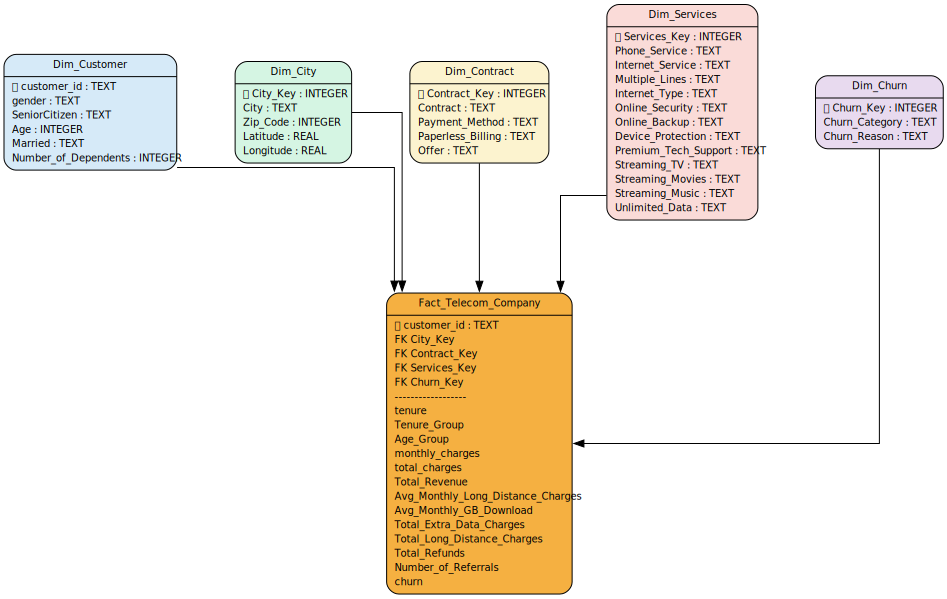

In [22]:
from graphviz import Digraph

dot = Digraph("Telecom_ERD", format="png")
dot.attr(rankdir="TB", splines="ortho", nodesep="0.8", ranksep="1")

# ---------- Style ----------
dot.attr("node",
         shape="record",
         style="rounded,filled",
         fontname="Segoe UI",
         fontsize="10")

# ---------- Dimension Tables ----------
dot.node("Customer",
'''{Dim_Customer|
🔑 customer_id : TEXT\l
gender : TEXT\l
SeniorCitizen : TEXT\l
Age : INTEGER\l
Married : TEXT\l
Number_of_Dependents : INTEGER\l
}''',
fillcolor="#D6EAF8")

dot.node("City",
'''{Dim_City|
🔑 City_Key : INTEGER\l
City : TEXT\l
Zip_Code : INTEGER\l
Latitude : REAL\l
Longitude : REAL\l
}''',
fillcolor="#D5F5E3")

dot.node("Contract",
'''{Dim_Contract|
🔑 Contract_Key : INTEGER\l
Contract : TEXT\l
Payment_Method : TEXT\l
Paperless_Billing : TEXT\l
Offer : TEXT\l
}''',
fillcolor="#FCF3CF")

dot.node("Services",
'''{Dim_Services|
🔑 Services_Key : INTEGER\l
Phone_Service : TEXT\l
Internet_Service : TEXT\l
Multiple_Lines : TEXT\l
Internet_Type : TEXT\l
Online_Security : TEXT\l
Online_Backup : TEXT\l
Device_Protection : TEXT\l
Premium_Tech_Support : TEXT\l
Streaming_TV : TEXT\l
Streaming_Movies : TEXT\l
Streaming_Music : TEXT\l
Unlimited_Data : TEXT\l
}''',
fillcolor="#FADBD8")

dot.node("Churn",
'''{Dim_Churn|
🔑 Churn_Key : INTEGER\l
Churn_Category : TEXT\l
Churn_Reason : TEXT\l
}''',
fillcolor="#E8DAEF")

# ---------- Fact Table ----------
dot.node("Fact",
'''{Fact_Telecom_Company|
🔑 customer_id : TEXT\l
FK City_Key\l
FK Contract_Key\l
FK Services_Key\l
FK Churn_Key\l
------------------\l
tenure\l
Tenure_Group\l
Age_Group\l
monthly_charges\l
total_charges\l
Total_Revenue\l
Avg_Monthly_Long_Distance_Charges\l
Avg_Monthly_GB_Download\l
Total_Extra_Data_Charges\l
Total_Long_Distance_Charges\l
Total_Refunds\l
Number_of_Referrals\l
churn\l
}''',
fillcolor="#F5B041")

# ---------- Relations ----------
dot.edge("Customer", "Fact")
dot.edge("City", "Fact")
dot.edge("Contract", "Fact")
dot.edge("Services", "Fact")
dot.edge("Churn", "Fact")

dot

<div style="
    background: linear-gradient(90deg, #111827, #B91C1C);
    color: white;
    padding: 20px;
    border-radius: 14px;
    text-align: center;
    font-family: Arial;
    margin: 18px 0;
">
    <h1 style="margin: 0;">Exploratory Data Analysis</h1>
    <p style="margin: 8px 0 0 0;">Charts and business insights from telecom churn data</p>
</div>

,City,Churn_Count
597,San Diego,185
390,Los Angeles,78
600,San Francisco,31
604,San Jose,29
230,Fallbrook,26


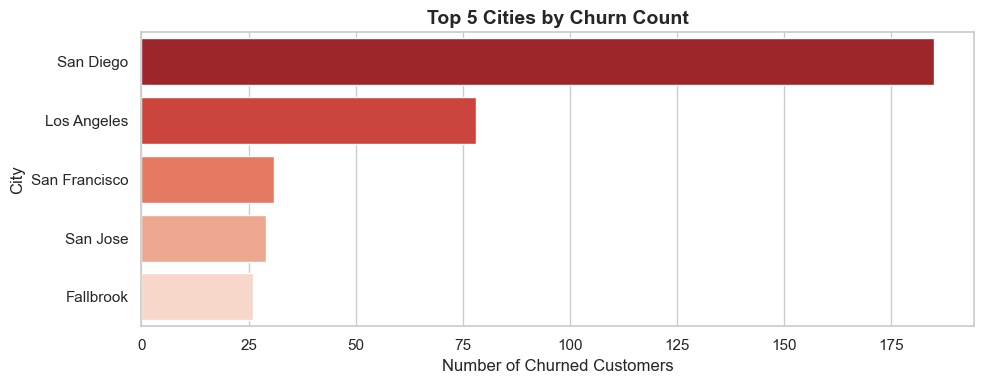

In [23]:
# 1. Top 5 Cities by Churn Count
# ------------------------------------------------------------------------------
top_5_cities = (
    fact_table
    .merge(dim_city, on='City_Key')
    .query("churn == 'Yes'")
    .groupby('City')
    .size()
    .reset_index(name='Churn_Count')
    .sort_values(by='Churn_Count', ascending=False)
    .head(5)
)
display(top_5_cities)

plt.figure(figsize=(10, 4))
sns.barplot(
    x='Churn_Count', y='City',
    data=top_5_cities,
    palette='Reds_r',
    hue='City', legend=False
)
plt.title('Top 5 Cities by Churn Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Churned Customers')
plt.ylabel('City')
plt.tight_layout()
plt.show()


=== 2. Churn Rate by Tenure Bucket ===


,Tenure_Group,Churn_Rate
0,0-12 months,47.44
1,13-24 months,28.71
2,25-48 months,20.39
3,49-72 months,9.51


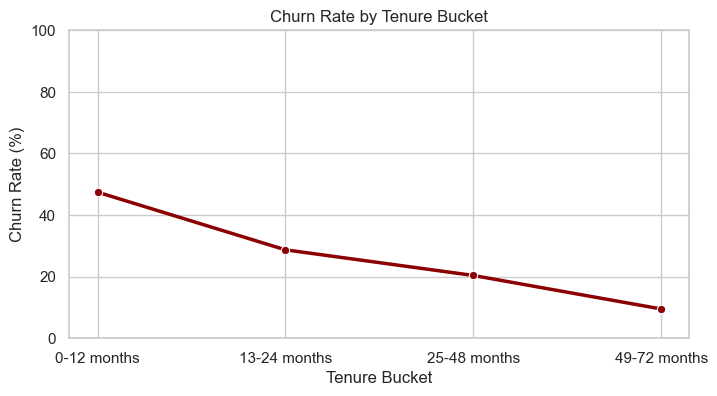

In [24]:
# ------------------------------------------------------------------------------]
# 2. Churn Rate by Tenure Bucket
# ------------------------------------------------------------------------------
print("=== 2. Churn Rate by Tenure Bucket ===")

churn_rate_tenure = (
    fact_table
    .groupby('Tenure_Group')
    .apply(lambda x: round(100.0 * (x['churn'] == 'Yes').sum() / len(x), 2))
    .reset_index(name='Churn_Rate')
    .sort_values(by='Tenure_Group')
)

display(churn_rate_tenure)

plt.figure(figsize=(8, 4))
sns.lineplot(
    x='Tenure_Group',
    y='Churn_Rate',
    data=churn_rate_tenure,
    marker='o',
    color='darkred',
    linewidth=2.5
)

plt.title('Churn Rate by Tenure Bucket')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure Bucket')
plt.ylim(0, 100)
plt.show()

=== 3. Churn by Contract ===


,Contract,Churn_Rate
0,Month-to-Month,45.84
1,One Year,10.71
2,Two Year,2.55


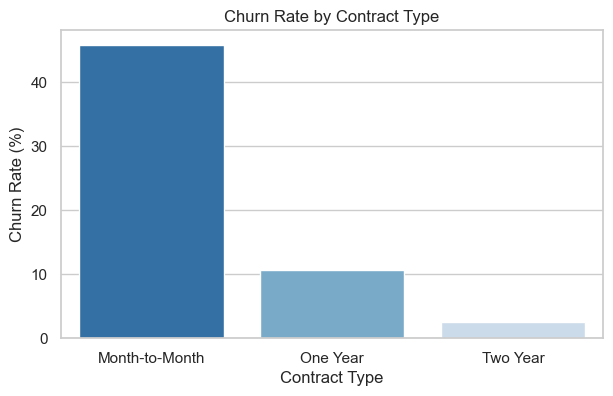

In [25]:
# ------------------------------------------------------------------------------
# 3. Churn by Contract 
# ------------------------------------------------------------------------------
print("=== 3. Churn by Contract ===")

df_contract = (
    fact_table
    .merge(dim_contract, on='Contract_Key')
)

churn_by_contract = (
    df_contract
    .groupby('Contract')
    .apply(lambda x: round(100.0 * (x['churn'] == 'Yes').sum() / len(x), 2))
    .reset_index(name='Churn_Rate')
)

display(churn_by_contract)

plt.figure(figsize=(7, 4))
sns.barplot(
    x='Contract',
    y='Churn_Rate',
    hue='Contract',
    data=churn_by_contract,
    palette='Blues_r',
    legend=False
)

plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.show()

=== 4. Top 5 Churn Reasons ===


,Churn_Reason,Reason_Count
2,Competitor had better devices,313
3,Competitor made better offer,311
1,Attitude of support person,220
7,Don't know,130
5,Competitor offered more data,117


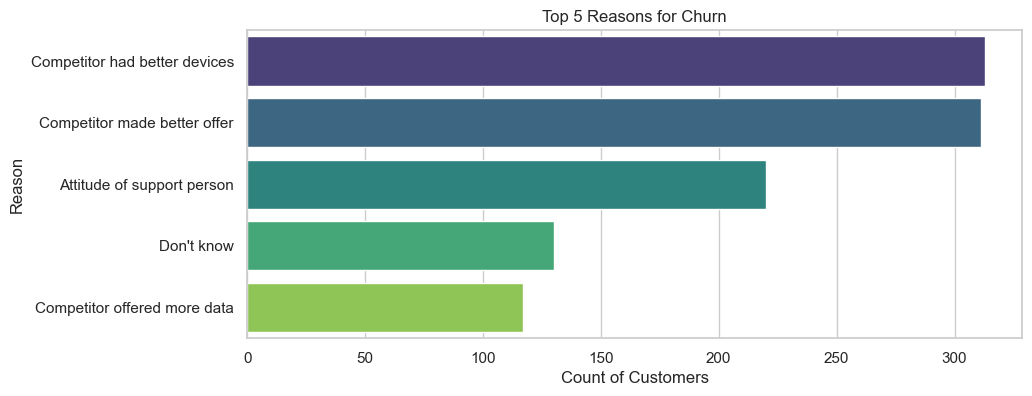

In [26]:
# ------------------------------------------------------------------------------
# 4. Top 5 Churn Reasons
# ------------------------------------------------------------------------------
print("=== 4. Top 5 Churn Reasons ===")

top_5_reasons = (
    fact_table
    .merge(dim_churn, on='Churn_Key')
    .query("churn == 'Yes'")
    .groupby('Churn_Reason')
    .size()
    .reset_index(name='Reason_Count')
    .sort_values(by='Reason_Count', ascending=False)
    .head(5)
)

display(top_5_reasons)

plt.figure(figsize=(10, 4))
sns.barplot(
    x='Reason_Count',
    y='Churn_Reason',
    hue='Churn_Reason',
    data=top_5_reasons,
    palette='viridis',
    legend=False
)

plt.title('Top 5 Reasons for Churn')
plt.xlabel('Count of Customers')
plt.ylabel('Reason')
plt.show()

=== 5. Revenue Lost by Churn Category ===


,Churn_Category,Revenue_Lost
0,Attitude,579758.38
1,Competitor,1693943.45
2,Dissatisfaction,618872.06
3,Other,353040.09
4,Price,438495.84


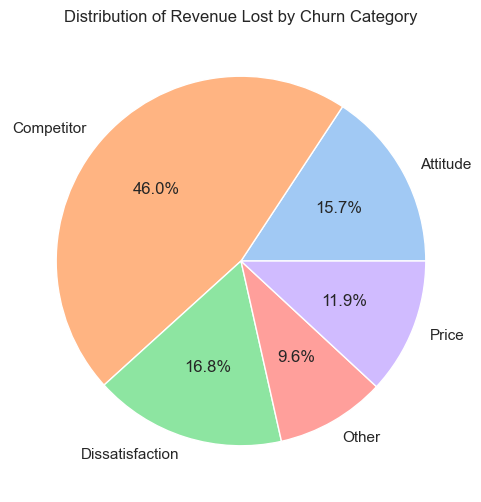

In [27]:
# ------------------------------------------------------------------------------
# 5. Revenue Lost by Churn Category
# ------------------------------------------------------------------------------
print("=== 5. Revenue Lost by Churn Category ===")

revenue_lost_cat = (
    fact_table
    .merge(dim_churn, on='Churn_Key')
    .query("churn == 'Yes'")
    .groupby('Churn_Category')['Total_Revenue']
    .sum()
    .reset_index(name='Revenue_Lost')
)

display(revenue_lost_cat)

plt.figure(figsize=(6, 6))
plt.pie(
    revenue_lost_cat['Revenue_Lost'],
    labels=revenue_lost_cat['Churn_Category'],
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel')
)

plt.title('Distribution of Revenue Lost by Churn Category')
plt.show()

=== 6. Revenue by Payment Method ===


,Payment_Method,Total_Revenue
0,Bank Withdrawal,12.67 M
1,Credit Card,8.16 M
2,Mailed Check,542.04 K


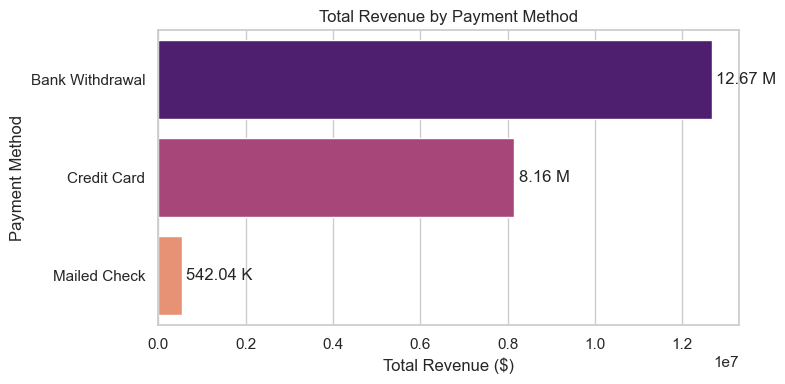

In [28]:
# ------------------------------------------------------------------------------
# 6. Revenue by Payment Method
# ------------------------------------------------------------------------------
print("=== 6. Revenue by Payment Method ===")

revenue_payment = (
    fact_table
    .merge(dim_contract, on='Contract_Key')
    .groupby('Payment_Method')['Total_Revenue']
    .sum()
    .reset_index(name='Total_Revenue')
    .sort_values(by='Total_Revenue', ascending=False)
)

def format_revenue(value):
    if value >= 1_000_000:
        return f"{round(value / 1_000_000, 2)} M"
    elif value >= 1_000:
        return f"{round(value / 1_000, 2)} K"
    else:
        return round(value, 2)

revenue_payment_display = revenue_payment.copy()
revenue_payment_display['Total_Revenue'] = revenue_payment_display['Total_Revenue'].apply(format_revenue)

display(revenue_payment_display)

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    x='Total_Revenue',
    y='Payment_Method',
    hue='Payment_Method',
    data=revenue_payment,
    palette='magma',
    legend=False
)

for container in ax.containers:
    labels = [format_revenue(v) for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3)

plt.title('Total Revenue by Payment Method')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Payment Method')
plt.tight_layout()
plt.show()


=== 7. Tech Support Analysis by Internet Type ===


,Internet_Type,Tech_Support_Yes,Tech_Support_No
0,Cable,398,432
1,DSL,790,862
2,Fiber Optic,856,2179


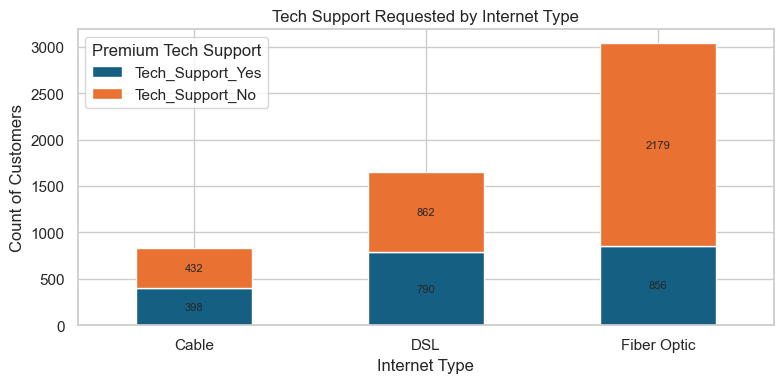

In [29]:
# ------------------------------------------------------------------------------
# 7. Tech Support Requested by Internet Type
# ------------------------------------------------------------------------------
print("=== 7. Tech Support Analysis by Internet Type ===")

df_tech = (
    fact_table
    .merge(dim_services, on='Services_Key')
)

df_tech = df_tech[
    df_tech['Internet_Type'] != 'No internet'
]

tech_support_analysis = (
    df_tech
    .groupby('Internet_Type')
    .agg(
        Tech_Support_Yes=(
            'Premium_Tech_Support',
            lambda x: (x == 'Yes').sum()
        ),
        Tech_Support_No=(
            'Premium_Tech_Support',
            lambda x: (x == 'No').sum()
        )
    )
    .reset_index()
)

display(tech_support_analysis)

ax = (
    tech_support_analysis
    .set_index('Internet_Type')[
        ['Tech_Support_Yes', 'Tech_Support_No']
    ]
    .plot(
        kind='bar',
        stacked=True,
        figsize=(8, 4),
           color=['#156082', '#E97132']
    )
)

for container in ax.containers:
    ax.bar_label(
        container,
        label_type='center',
        fontsize=8
    )

plt.title('Tech Support Requested by Internet Type')
plt.xlabel('Internet Type')
plt.ylabel('Count of Customers')
plt.legend(title='Premium Tech Support')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

=== Avg Revenue by Married Status ===


,Married,Avg_Revenue
0,Married,4009.97
1,Not Married,2122.53


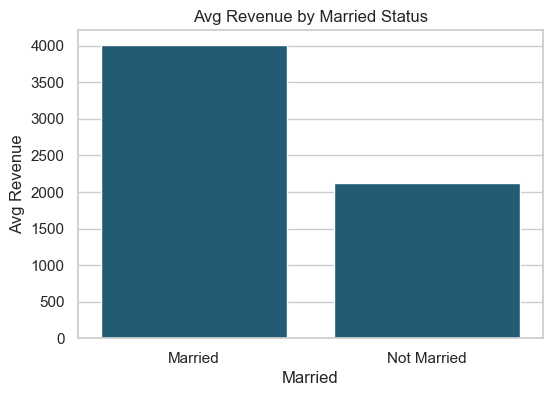

In [30]:
# ==============================================================================
#8. Avg Revenue by Married Status
# ==============================================================================
print("=== Avg Revenue by Married Status ===")

avg_revenue_married = (
    fact_table
    .merge(dim_customer, on='customer_id')
    .groupby('Married')['Total_Revenue']
    .mean()
    .round(2)
    .reset_index(name='Avg_Revenue')
)

display(avg_revenue_married)

plt.figure(figsize=(6, 4))
sns.barplot(
    x='Married',
    y='Avg_Revenue',
    hue='Married',
    data=avg_revenue_married,
    palette=['#156082'],
    legend=False
)
plt.title('Avg Revenue by Married Status')
plt.xlabel('Married')
plt.ylabel('Avg Revenue')
plt.show()


=== Revenue by Contract Duration ===


,Contract,Total_Revenue
2,Two Year,9.04 M
1,One Year,6.17 M
0,Month-to-Month,6.16 M


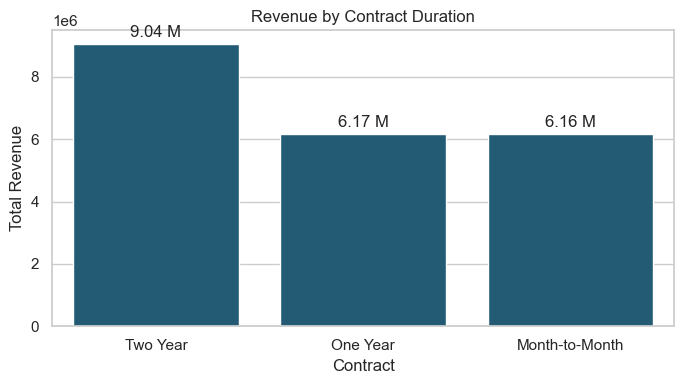

In [31]:
# ==============================================================================
#9. Revenue by Contract Duration
# ==============================================================================
print("=== Revenue by Contract Duration ===")

revenue_contract = (
    fact_table
    .merge(dim_contract, on='Contract_Key')
    .groupby('Contract')['Total_Revenue']
    .sum()
    .reset_index(name='Total_Revenue')
    .sort_values(by='Total_Revenue', ascending=False)
)

revenue_contract_display = revenue_contract.copy()
revenue_contract_display['Total_Revenue'] = (
    revenue_contract_display['Total_Revenue'] / 1_000_000
).round(2).astype(str) + ' M'

display(revenue_contract_display)

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    x='Contract',
    y='Total_Revenue',
    hue='Contract',
    data=revenue_contract,
   palette=['#156082'],
    legend=False
)

for container in ax.containers:
    labels = [f"{round(v / 1_000_000, 2)} M" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3)

plt.title('Revenue by Contract Duration')
plt.xlabel('Contract')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

=== Churn Rate: Senior vs Non-Senior ===


,Senior_Group,churn,Count,Percentage
0,Non-Senior,No,4508,76.39
1,Non-Senior,Yes,1393,23.61
2,Senior,No,666,58.32
3,Senior,Yes,476,41.68


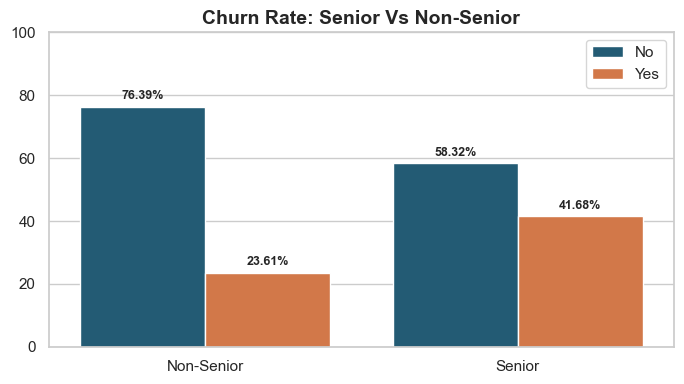

In [32]:
# ==============================================================================
#10. Churn Rate: Senior vs Non-Senior
# ==============================================================================
print("=== Churn Rate: Senior vs Non-Senior ===")

df_senior = fact_table.merge(dim_customer, on='customer_id')

df_senior['Senior_Group'] = df_senior['SeniorCitizen'].map({
    0: 'Non-Senior',
    1: 'Senior'
})

senior_churn_plot = (
    df_senior
    .groupby(['Senior_Group', 'churn'])
    .size()
    .reset_index(name='Count')
)

senior_churn_plot['Percentage'] = (
    senior_churn_plot
    .groupby('Senior_Group')['Count']
    .transform(lambda x: round(100 * x / x.sum(), 2))
)

display(senior_churn_plot)

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    x='Senior_Group',
    y='Percentage',
    hue='churn',
    data=senior_churn_plot,
palette=['#156082', '#E97132'])

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3,
        fontsize=9,
        fontweight='bold'
    )

plt.title('Churn Rate: Senior Vs Non-Senior', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.ylim(0, 100)
plt.legend(title='', loc='upper right')

plt.tight_layout()
plt.show()


<div style="
    background: linear-gradient(90deg, #581C87, #A855F7);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Summary KPIs Dashboard</h2>
    <p style="margin: 6px 0 0 0;">Display final business KPIs for churn analysis.</p>
</div>

In [33]:
# ------------------------------------------------------------------------------
# 8. KPIs Dashboard
# ------------------------------------------------------------------------------
print("=== 8. Summary KPIs Dashboard ===")

df_kpi_churn = fact_table.merge(
    dim_churn,
    on='Churn_Key'
)

df_fiber = (
    fact_table
    .merge(dim_services, on='Services_Key')
    .merge(dim_churn, on='Churn_Key')
)

df_customer_kpi = fact_table.merge(
    dim_customer,
    on='customer_id'
)

df_senior_kpi = df_customer_kpi[
    df_customer_kpi['SeniorCitizen'] == 1
]

kpis = {
    "Total Customers": len(fact_table),

    "Total Churned Customers": (
        fact_table['churn'] == 'Yes'
    ).sum(),

    "Overall Churn Rate": f"{round(100.0 * (fact_table['churn'] == 'Yes').sum() / len(fact_table), 2)}%",

    "Total Revenue": f"${round(fact_table['Total_Revenue'].sum(), 2):,}",

    "Total Revenue Lost": f"${round(fact_table[fact_table['churn'] == 'Yes']['Total_Revenue'].sum(), 2):,}",

    "Avg Revenue (Married)": f"${round(df_customer_kpi[df_customer_kpi['Married'] == 'Yes']['Total_Revenue'].mean(), 2)}",

    "Senior Citizen Churn Rate": f"{round(100.0 * (df_senior_kpi['churn'] == 'Yes').sum() / len(df_senior_kpi), 2)}%",

    "Fiber Optic Churn Count": len(
        df_fiber[
            (df_fiber['Internet_Type'] == 'Fiber Optic') &
            (df_fiber['churn'] == 'Yes')
        ]
    )
}

for k, v in kpis.items():
    print(f"{k:<30} : {v}")

=== 8. Summary KPIs Dashboard ===
Total Customers                : 7043
Total Churned Customers        : 1869
Overall Churn Rate             : 26.54%
Total Revenue                  : $21,370,053.9
Total Revenue Lost             : $3,684,109.82
Avg Revenue (Married)          : $nan
Senior Citizen Churn Rate      : 41.68%
Fiber Optic Churn Count        : 1236


<div style="
    background: linear-gradient(90deg, #020617, #7F1D1D);
    color: white;
    padding: 22px;
    border-radius: 14px;
    text-align: center;
    font-family: Arial;
    margin: 18px 0;
">
    <h1 style="margin: 0;">Statistical Analysis</h1>
    <p style="margin: 8px 0 0 0;">Descriptive Statistics, Hypothesis Testing, ANOVA, T-Test, and Regression Analysis</p>
</div>

In [34]:
df_fact = pd.read_excel("Fact_Telecom_Customers.xlsx")

print("Fact dataset shape:", df_fact.shape)
display(df_fact.head())

Fact dataset shape: (7043, 23)


,customer_id,City_Key,Contract_Key,Services_Key,churn_key,Gender,SeniorCitizen,Age,Age_Group,Married,Number of Dependents,Number of Referrals,tenure,Tenure_Group,Avg Monthly Long Distance Charges,Avg Monthly GB Download,monthly_charges,total_charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,churn
0,0002-ORFBO,1,1,1,1,Female,Non-Senior,37,31-45,Married,0,2,9,0-12 months,42.39,16,65.60,590.40,0.00,0,381.51,971.91,No
1,6689-VRRTK,9,1,105,1,Female,Senior,71,+'60,Not Married,0,0,44,25-48 months,49.75,2,109.80,4831.20,0.00,0,2189.00,7020.20,No
2,2673-CXQEU,148,7,105,1,Female,Senior,73,+'60,Not Married,0,0,56,49-72 months,47.13,29,110.50,6188.00,0.00,0,2639.28,8827.28,No
3,7590-VHVEG,2,2,2,1,Female,Non-Senior,36,31-45,Married,0,0,1,0-12 months,0.00,10,29.85,29.85,0.00,0,0.00,29.85,No
4,0975-VOOVL,347,3,2,1,Female,Non-Senior,34,31-45,Not Married,0,0,3,0-12 months,0.00,22,29.20,87.60,0.00,0,0.00,87.60,No


<div style="
    background: linear-gradient(90deg, #1E40AF, #3B82F6);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Descriptive Statistics - Monthly Charges</h2>
    <p style="margin: 6px 0 0 0;">Summarize the distribution of monthly customer charges.</p>
</div>

In [35]:
descriptive_stats =df_fact['monthly_charges'].describe()
print("---Descriptive statistics Table---")
print(descriptive_stats)


---Descriptive statistics Table---
count   7043.00
mean      64.76
std       30.09
min       18.25
25%       35.50
50%       70.35
75%       89.85
max      118.75
Name: monthly_charges, dtype: float64


<div style="
    background: linear-gradient(90deg, #075985, #0EA5E9);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Monthly Charges Distribution</h2>
    <p style="margin: 6px 0 0 0;">Visualize customer monthly charges and identify the average charge.</p>
</div>

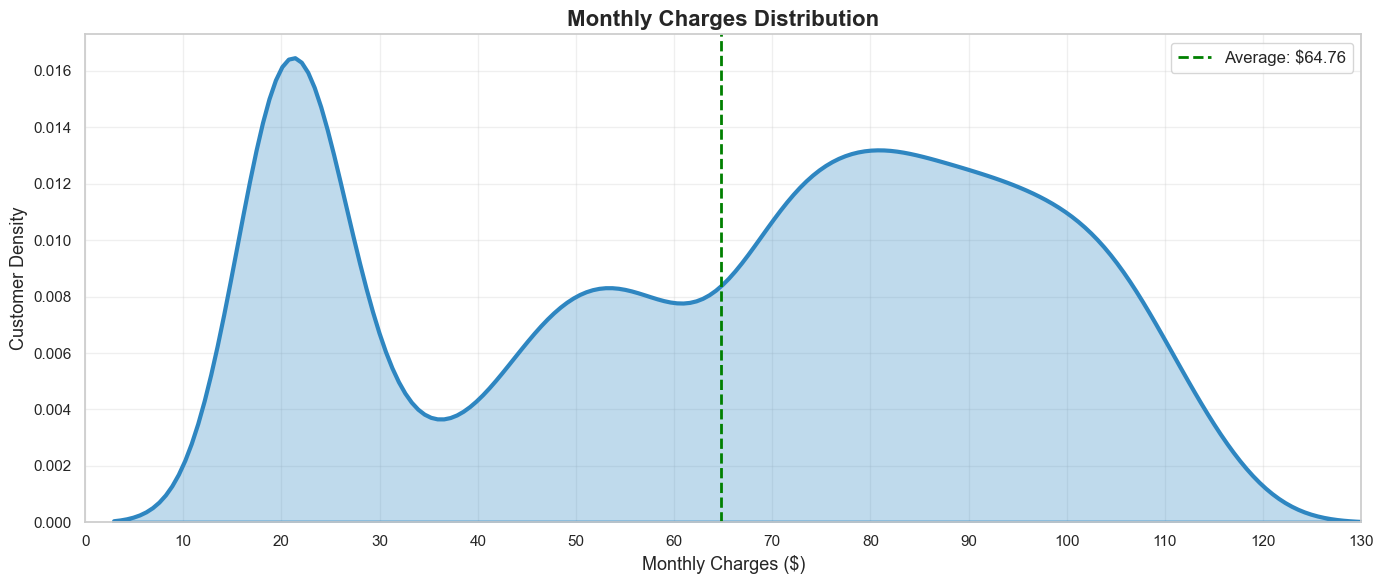

Statistical Insight

Most customers pay between $35 and $90 per month, with the highest concentration around $70.
This suggests that the company's pricing strategy is well-aligned with the majority of its customer base.
However, the long tail extending beyond $100 indicates a smaller segment of high-value customers.
These customers may be at higher risk of churn due to their elevated monthly bills.


In [36]:
df_fact = pd.read_excel('Fact_Telecom_Customers.xlsx')

plt.figure(figsize=(14, 6))

sns.kdeplot(df_fact['monthly_charges'], color='#2E86C1', linewidth=3, fill=True, alpha=0.3)

mean_charge = df_fact['monthly_charges'].mean()
plt.axvline(mean_charge, color='green', linestyle='--', linewidth=2, label=f'Average: ${mean_charge:.2f}')

plt.title('Monthly Charges Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Monthly Charges ($)', fontsize=13)
plt.ylabel('Customer Density', fontsize=13)
plt.xlim(0, 130)
plt.xticks(range(0, 131, 10))
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print("="*60)
print("Statistical Insight")
print("="*60)

print("\nMost customers pay between $35 and $90 per month, with the highest concentration around $70.")
print("This suggests that the company's pricing strategy is well-aligned with the majority of its customer base.")
print("However, the long tail extending beyond $100 indicates a smaller segment of high-value customers.")
print("These customers may be at higher risk of churn due to their elevated monthly bills.")

<div style="
    background: linear-gradient(90deg, #581C87, #9333EA);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Chi-Square Test - Gender and Churn</h2>
    <p style="margin: 6px 0 0 0;">Test whether gender has a significant relationship with customer churn.</p>
</div>

In [37]:
# 1. Create a simple table for Gender and Churn
my_table = pd.crosstab(df_fact['Gender'], df_fact['churn'])

# 2. Run the Chi-Square test
chi2, p_value, dof, expected = stats.chi2_contingency(my_table)

# 3. Print only the p-value
print("p-value is:", p_value)                   

p-value is: 0.48657873605618596


<div style="
    background: linear-gradient(90deg, #6B21A8, #A855F7);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Gender Distribution and Churn Rate</h2>
    <p style="margin: 6px 0 0 0;">Compare gender distribution and churn behavior by gender.</p>
</div>

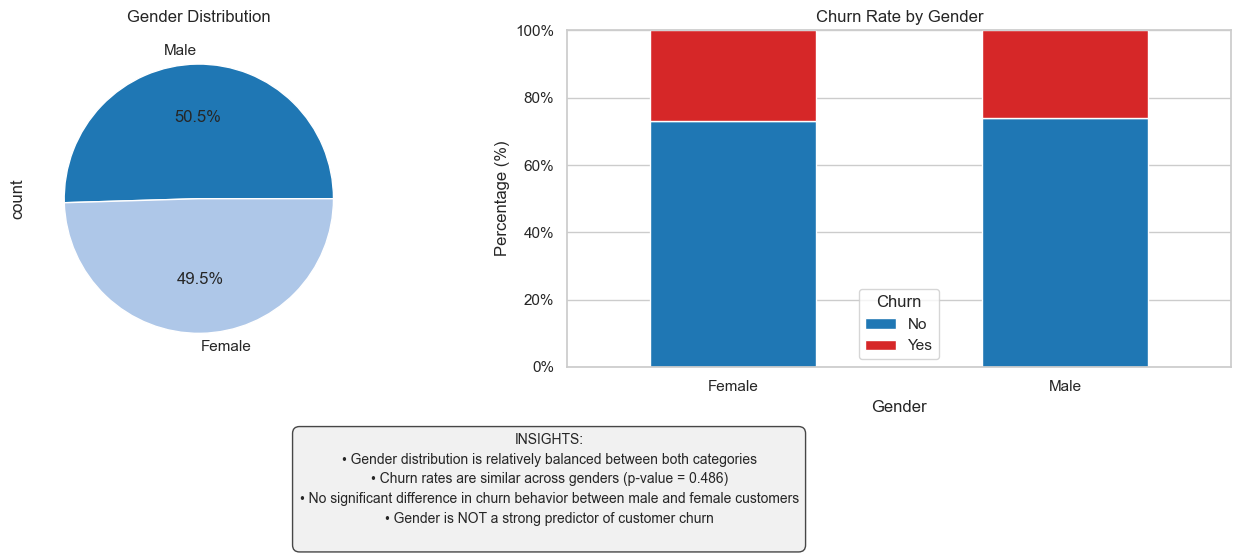

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie Chart - Blue and Light Blue
colors = ['#1F77B4', '#AEC7E8']
df_fact['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0], colors=colors)
axes[0].set_title('Gender Distribution')

# Stacked Bar - Blue for No, Real Red for Yes
colors_bar = ['#1F77B4', '#D62728']
pd.crosstab(df_fact['Gender'], df_fact['churn'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[1], color=colors_bar
)
axes[1].set_title('Churn Rate by Gender')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_ylim(0, 1)
axes[1].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[1].set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
axes[1].legend(title='Churn', labels=['No', 'Yes'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()

# Insights - separate box below
insights_text = """INSIGHTS:
• Gender distribution is relatively balanced between both categories
• Churn rates are similar across genders (p-value = 0.486)
• No significant difference in churn behavior between male and female customers
• Gender is NOT a strong predictor of customer churn
"""

# Add text box at the bottom
plt.figtext(0.5, -0.1, insights_text, ha='center', fontsize=10, 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#F0F0F0', edgecolor='#333', alpha=0.9),
            linespacing=1.5)

plt.subplots_adjust(bottom=0.25)
plt.show()

<div style="
    background: linear-gradient(90deg, #7C2D12, #EA580C);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Chi-Square Test - Marital Status and Churn</h2>
    <p style="margin: 6px 0 0 0;">Test whether marital status has a significant relationship with churn.</p>
</div>

In [39]:
# 1. Create a simple table for martial and Churn
married_table = pd.crosstab(df_fact['Married'], df_fact['churn'])

# 2. Run the Chi-Square test
chi2, p_value, dof, expected = stats.chi2_contingency(married_table,correction=False)

# 3. Print only the p-value
print("p-value is:", p_value)  

p-value is: 1.519036620099736e-36


<div style="
    background: linear-gradient(90deg, #92400E, #F97316);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Marital Status Distribution and Churn Rate</h2>
    <p style="margin: 6px 0 0 0;">Compare marital status distribution and churn behavior.</p>
</div>

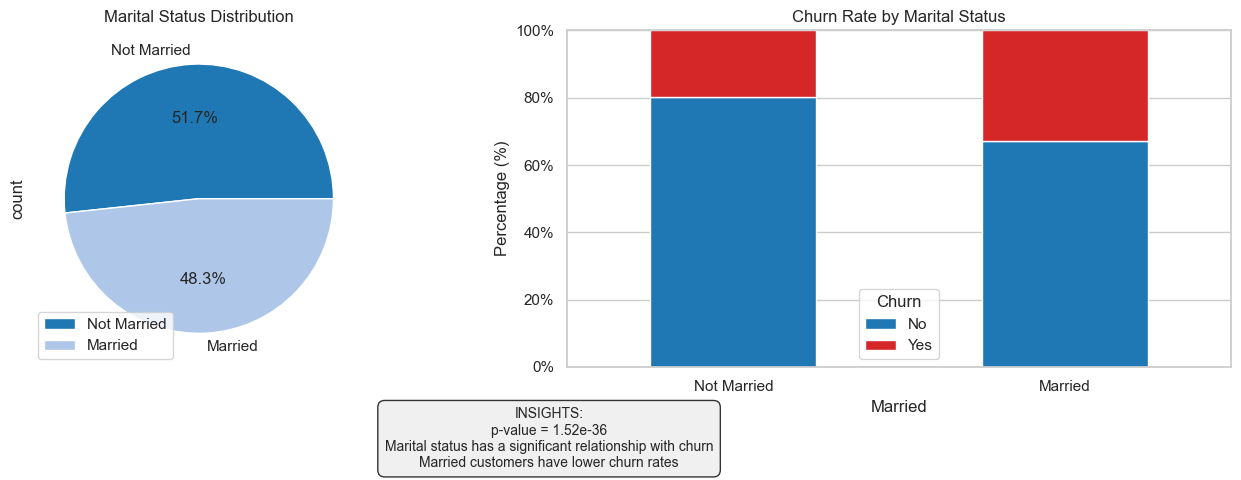

In [40]:
# Chi-Square Test for Marital Status
married_table = pd.crosstab(df_fact['Married'], df_fact['churn'])
chi2, p_value, dof, expected = stats.chi2_contingency(married_table, correction=False)

# Create Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie Chart
df_fact['Married'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax1, colors=['#1F77B4', '#AEC7E8'])
ax1.set_title('Marital Status Distribution')
ax1.legend(['Not Married', 'Married'])

# Stacked Bar - Blue for No, Red for Yes
pd.crosstab(df_fact['Married'], df_fact['churn'], normalize='index').plot(
    kind='bar', stacked=True, ax=ax2, color=['#1F77B4', '#D62728']
)
ax2.set_title('Churn Rate by Marital Status')
ax2.set_ylabel('Percentage (%)')
ax2.set_ylim(0, 1)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax2.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.legend(title='Churn', labels=['No', 'Yes'])
ax2.set_xticklabels(['Not Married', 'Married'])
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

# Insights
insights_text = f"""INSIGHTS:
p-value = {p_value:.2e}
Marital status has a significant relationship with churn
Married customers have lower churn rates"""

plt.figtext(0.5, 0.05, insights_text, ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#F0F0F0', edgecolor='#333'))

plt.show()

<div style="
    background: linear-gradient(90deg, #92400E, #F59E0B);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Chi-Square Test - Senior Citizen and Churn</h2>
    <p style="margin: 6px 0 0 0;">Test whether senior citizen status has a significant relationship with churn.</p>
</div>

In [41]:
# 1. Create a simple table for martial and Churn
married_table = pd.crosstab(df_fact['SeniorCitizen'], df_fact['churn'])

# 2. Run the Chi-Square test
chi2, p_value, dof, expected = stats.chi2_contingency(married_table,correction=False)

# 3. Print only the p-value
print("p-value is:", p_value)  

p-value is: 9.477903507376051e-37


<div style="
    background: linear-gradient(90deg, #B45309, #FBBF24);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Senior Citizen Distribution and Churn Rate</h2>
    <p style="margin: 6px 0 0 0;">Compare senior and non-senior customers based on churn behavior.</p>
</div>

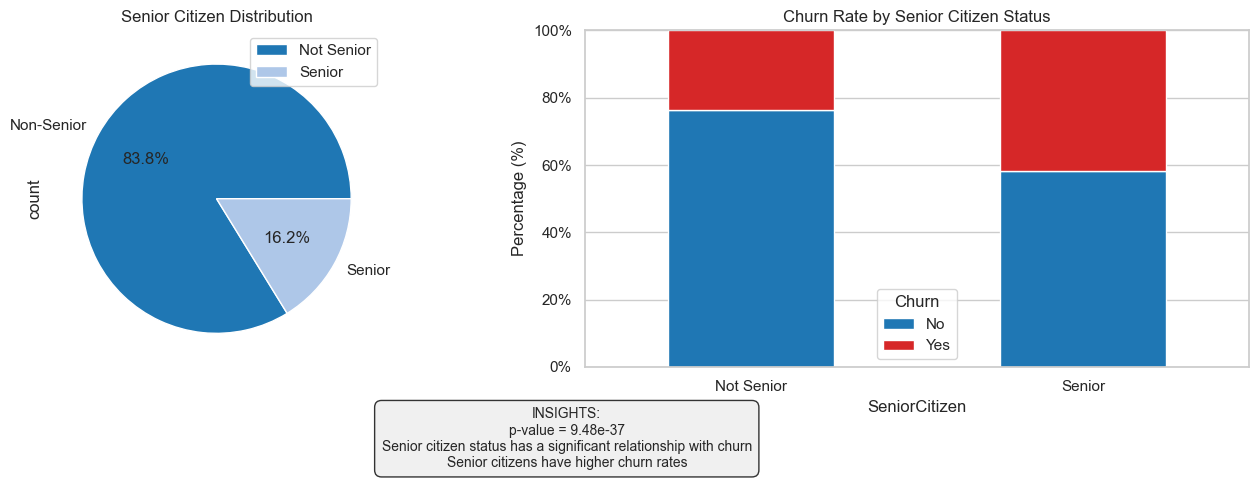

In [42]:
# Chi-Square Test for Senior Citizen
senior_table = pd.crosstab(df_fact['SeniorCitizen'], df_fact['churn'])
chi2, p_value, dof, expected = stats.chi2_contingency(senior_table, correction=False)

# Create Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie Chart
df_fact['SeniorCitizen'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax1, colors=['#1F77B4', '#AEC7E8'])
ax1.set_title('Senior Citizen Distribution')
ax1.legend(['Not Senior', 'Senior'])

# Stacked Bar - Blue for No, Red for Yes
pd.crosstab(df_fact['SeniorCitizen'], df_fact['churn'], normalize='index').plot(
    kind='bar', stacked=True, ax=ax2, color=['#1F77B4', '#D62728']
)
ax2.set_title('Churn Rate by Senior Citizen Status')
ax2.set_ylabel('Percentage (%)')
ax2.set_ylim(0, 1)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax2.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.legend(title='Churn', labels=['No', 'Yes'])
ax2.set_xticklabels(['Not Senior', 'Senior'])
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

# Insights
insights_text = f"""INSIGHTS:
p-value = {p_value:.2e}
Senior citizen status has a significant relationship with churn
Senior citizens have higher churn rates"""

plt.figtext(0.5, 0.05, insights_text, ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#F0F0F0', edgecolor='#333'))

plt.show()

<div style="
    background: linear-gradient(90deg, #1D4ED8, #60A5FA);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Chi-Square Test - Contract and Churn</h2>
    <p style="margin: 6px 0 0 0;">Test whether contract type has a significant relationship with churn.</p>
</div>

In [43]:
contract_table = pd.crosstab(df_fact["Contract_Key"], df_fact["churn"])

chi2, p_value, dof, expected = stats.chi2_contingency(
    contract_table,
    correction=False
)
# 3. Print only the p-value
print("p-value is:", p_value)  

print("=" * 60)
print("INSIGHTS FOR CONTRACT TYPE & CHURN")
print("=" * 60)
print(f"p-value: {p_value:.2e}")
print("-" * 60)

if p_value < 0.05:
    print("Relationship is SIGNIFICANT because p-value < 0.05")
    print("Contract type is a strong predictor of customer churn.")
else:
    print("Relationship is NOT SIGNIFICANT because p-value >= 0.05")
    print("Contract type is not a strong predictor of customer churn.")

print("=" * 60)

p-value is: 0.0
INSIGHTS FOR CONTRACT TYPE & CHURN
p-value: 0.00e+00
------------------------------------------------------------
Relationship is SIGNIFICANT because p-value < 0.05
Contract type is a strong predictor of customer churn.


<div style="
    background: linear-gradient(90deg, #312E81, #6366F1);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">ANOVA Test - Contract Type and Monthly Charges</h2>
    <p style="margin: 6px 0 0 0;">Compare average monthly charges across different contract types.</p>
</div>

In [44]:
# 1. Map the contract keys to text names to match Excel groups
contract_map = {1: 'Month-to-Month', 2: 'One Year', 3: 'Two Year'}
df_fact['Contract_Name'] = df_fact['Contract_Key'].map(contract_map)

# 2. Group Summary (Count, Sum, Average, Variance)
print("--- Group Summary ---")
summary = df_fact.groupby('Contract_Name')['monthly_charges'].agg(['count', 'sum', 'mean', 'var'])
summary.columns = ['Count', 'Sum', 'Average', 'Variance']
print(summary)
print("\n" + "="*50 + "\n")

# 3. ANOVA Table like Excel
print("--- ANOVA Table ---")
model = ols('monthly_charges ~ C(Contract_Name)', data=df_fact).fit()
anova_table = sm.stats.anova_lm(model, typ=1)

# Rename columns and rows to match Excel exactly
anova_table.columns = ['df', 'SS', 'MS', 'F', 'P-value']
anova_table.index = ['Between Groups', 'Within Groups']

print(anova_table)

--- Group Summary ---
                Count      Sum  Average  Variance
Contract_Name                                    
Month-to-Month    179 11928.30    66.64    924.42
One Year          302 20904.40    69.22    477.95
Two Year          277 11743.95    42.40    661.51


--- ANOVA Table ---
                   df        SS       MS     F  P-value
Between Groups   2.00 118317.26 59158.63 90.97     0.00
Within Groups  755.00 490985.49   650.31   NaN      NaN


<div style="
    background: linear-gradient(90deg, #4338CA, #818CF8);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Monthly Charges by Contract Type</h2>
    <p style="margin: 6px 0 0 0;">Visualize average and distribution of monthly charges by contract type.</p>
</div>

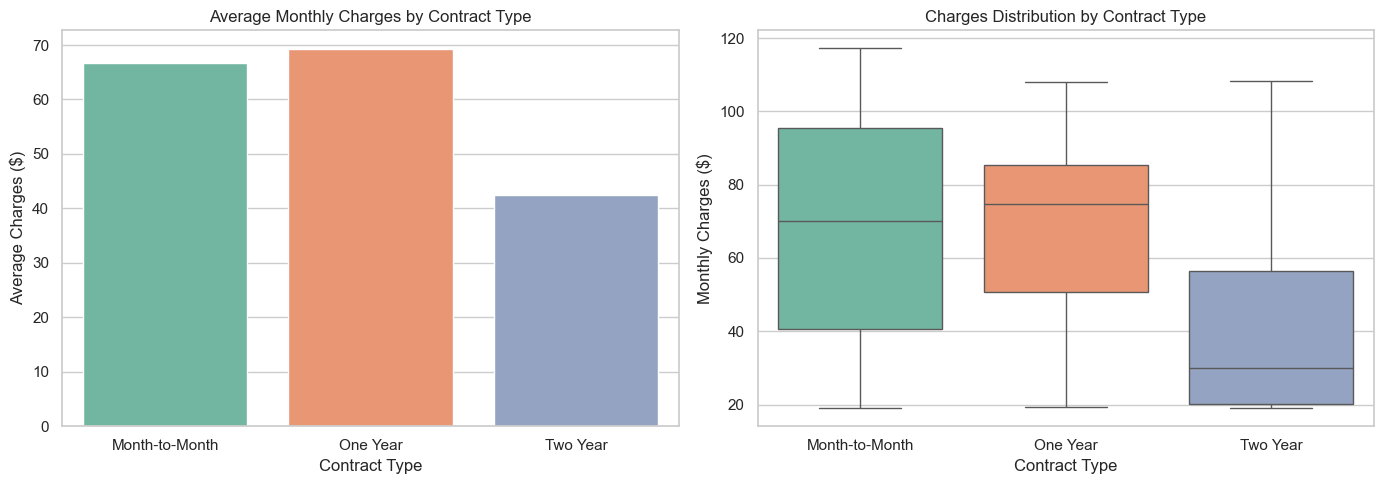

In [45]:
# 1. Setup the screen for 2 charts side-by-side
plt.figure(figsize=(14, 5))

# 2. Chart 1: Bar Plot (Cleaned from warnings)
plt.subplot(1, 2, 1)
sns.barplot(x='Contract_Name', y='monthly_charges', data=df_fact, hue='Contract_Name', errorbar=None, palette='Set2', legend=False)
plt.title("Average Monthly Charges by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Average Charges ($)")

# 3. Chart 2: Box Plot (Cleaned from warnings)
plt.subplot(1, 2, 2)
sns.boxplot(x='Contract_Name', y='monthly_charges', data=df_fact, hue='Contract_Name', palette='Set2', legend=False)
plt.title("Charges Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Monthly Charges ($)")

# 4. Perfect spacing
plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(90deg, #9F1239, #F43F5E);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">T-Test - Monthly Charges by Churn</h2>
    <p style="margin: 6px 0 0 0;">Compare monthly charges between churned and non-churned customers.</p>
</div>

In [46]:
# =========================================================================
# 1️⃣ T-Test: monthly_charges by Churn
# =========================================================================
charges_yes = df_fact[df_fact['churn'] == 'Yes']['monthly_charges']
charges_no = df_fact[df_fact['churn'] == 'No']['monthly_charges']

summary_charges = pd.DataFrame({
    'Yes': [charges_yes.mean(), charges_yes.var(), charges_yes.count()],
    'No': [charges_no.mean(), charges_no.var(), charges_no.count()]
}, index=['Mean', 'Variance', 'Observations'])

t_stat_c, p_val_c = stats.ttest_ind(charges_yes, charges_no, equal_var=False)

df_c = len(charges_yes) + len(charges_no) - 2
t_crit_1tail_c = stats.t.ppf(1 - 0.05, df_c)
t_crit_2tail_c = stats.t.ppf(1 - 0.025, df_c)

print("======== monthly_charges T-Test Result ========")
print(summary_charges.round(3))
print("-" * 40)
print(f"t Stat:              {t_stat_c:.4f}")
print(f"P-value (1-tail):    {p_val_c/2}")
print(f"t Critical (1-tail): {t_crit_1tail_c:.4f}")
print(f"P-value (2-tail):    {p_val_c}")
print(f"t Critical (2-tail): {t_crit_2tail_c:.4f}")
print("===============================================\n")


# =========================================================================
# 2️⃣ T-Test: tenure by Churn
# =========================================================================
tenure_column = 'tenure' if 'tenure' in df_fact.columns else 'Tenure_Months'

tenure_yes = df_fact[df_fact['churn'] == 'Yes'][tenure_column]
tenure_no = df_fact[df_fact['churn'] == 'No'][tenure_column]

summary_tenure = pd.DataFrame({
    'Yes': [tenure_yes.mean(), tenure_yes.var(), tenure_yes.count()],
    'No': [tenure_no.mean(), tenure_no.var(), tenure_no.count()]
}, index=['Mean', 'Variance', 'Observations'])

t_stat_t, p_val_t = stats.ttest_ind(tenure_yes, tenure_no, equal_var=False)

df_t = len(tenure_yes) + len(tenure_no) - 2
t_crit_1tail_t = stats.t.ppf(1 - 0.05, df_t)
t_crit_2tail_t = stats.t.ppf(1 - 0.025, df_t)

print("======== tenure T-Test Result ========")
print(summary_tenure.round(3))
print("-" * 40)
print(f"t Stat:              {t_stat_t:.4f}")
print(f"P-value (1-tail):    {p_val_t/2}")
print(f"t Critical (1-tail): {t_crit_1tail_t:.4f}")
print(f"P-value (2-tail):    {p_val_t}")
print(f"t Critical (2-tail): {t_crit_2tail_t:.4f}")
print("===============================================")

======== monthly_charges T-Test Result ========
                 Yes      No
Mean           74.44   61.27
Variance      608.41  966.75
Observations 1869.00 5174.00
----------------------------------------
t Stat:              18.4075
P-value (1-tail):    4.2962246657705844e-73
t Critical (1-tail): 1.6451
P-value (2-tail):    8.592449331541169e-73
t Critical (2-tail): 1.9603

======== tenure T-Test Result ========
                 Yes      No
Mean           17.98   37.59
Variance      381.46  580.09
Observations 1869.00 5174.00
----------------------------------------
t Stat:              -34.8764
P-value (1-tail):    1.5788719423383425e-233
t Critical (1-tail): 1.6451
P-value (2-tail):    3.157743884676685e-233
t Critical (2-tail): 1.9603


<div style="
    background: linear-gradient(90deg, #BE123C, #FB7185);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Monthly Charges by Churn</h2>
    <p style="margin: 6px 0 0 0;">Visualize average and distribution of monthly charges by churn status.</p>
</div>

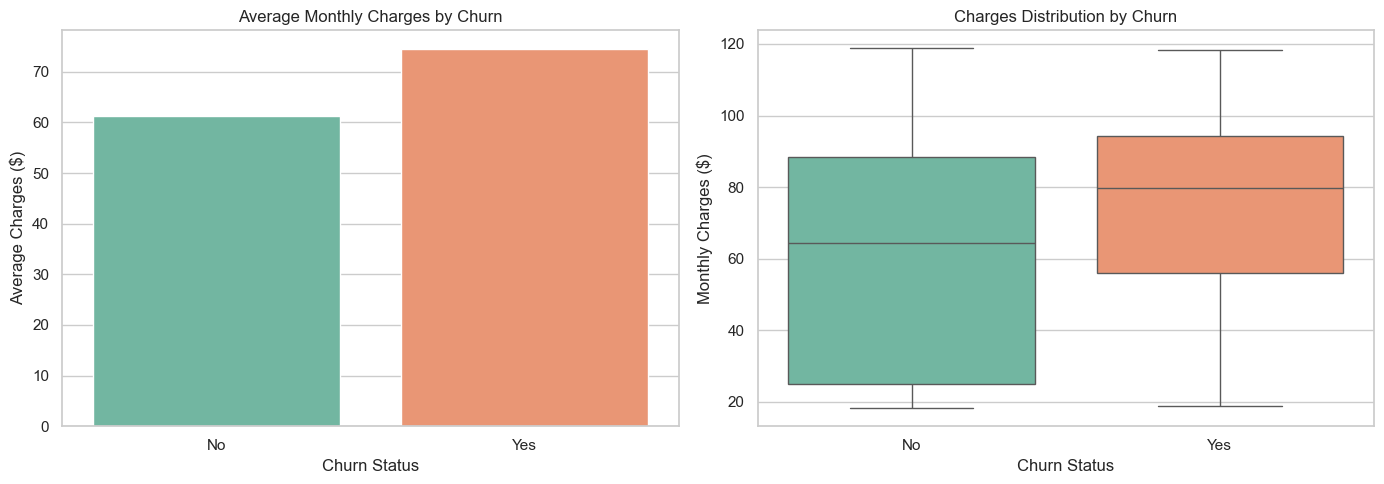

In [47]:
#monthly churn box plot 
plt.figure(figsize=(14, 5))

# 1. Chart 1: Bar Plot (Average monthly_charges by Churn)
plt.subplot(1, 2, 1)
sns.barplot(x='churn', y='monthly_charges', data=df_fact, hue='churn', errorbar=None, palette='Set2', legend=False)
plt.title("Average Monthly Charges by Churn")
plt.xlabel("Churn Status")
plt.ylabel("Average Charges ($)")

# 2. Chart 2: Box Plot (Distribution of monthly_charges by Churn)
plt.subplot(1, 2, 2)
sns.boxplot(x='churn', y='monthly_charges', data=df_fact, hue='churn', palette='Set2', legend=False)
plt.title("Charges Distribution by Churn")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges ($)")

plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(90deg, #065F46, #10B981);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Tenure by Churn</h2>
    <p style="margin: 6px 0 0 0;">Compare average tenure and tenure distribution by churn status.</p>
</div>

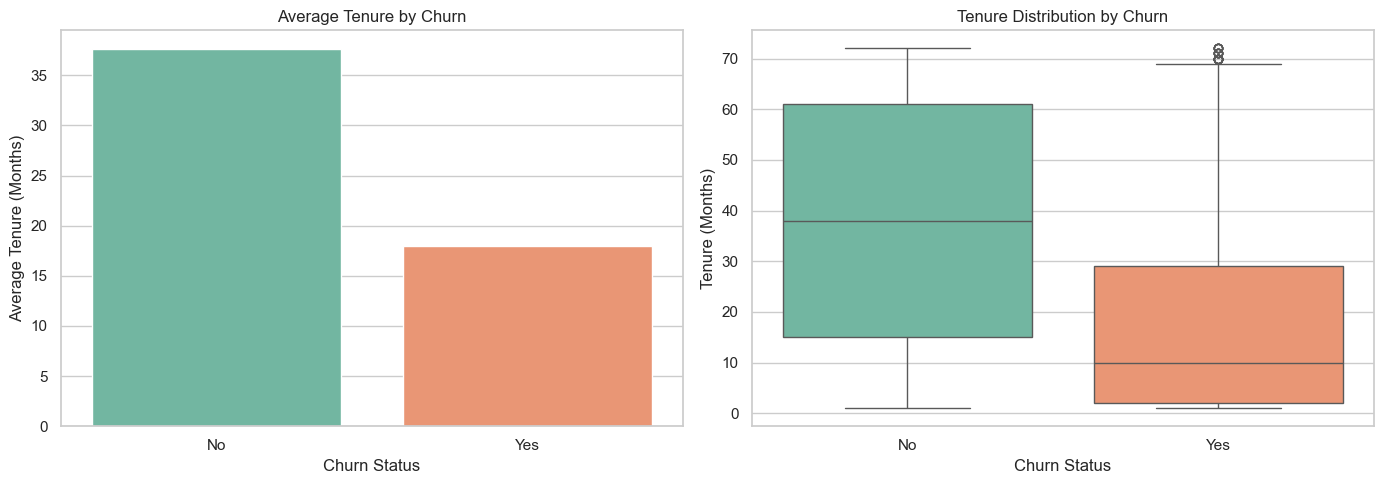

In [48]:
#Box plot of tenure

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='churn', y='tenure', data=df_fact, hue='churn', errorbar=None, palette='Set2', legend=False)
plt.title("Average Tenure by Churn")
plt.xlabel("Churn Status")
plt.ylabel("Average Tenure (Months)")
plt.subplot(1, 2, 2)
sns.boxplot(x='churn', y='tenure', data=df_fact, hue='churn', palette='Set2', legend=False)
plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(90deg, #0F172A, #2563EB);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Regression Analysis</h2>
    <p style="margin: 6px 0 0 0;">Analyze how referrals, tenure, and monthly charges affect churn.</p>
</div>

In [49]:
# 1. Create churn_numeric column from the 'churn' column (Yes=1, No=0)
df_fact['churn_numeric'] = df_fact['churn'].map({'Yes': 1, 'No': 0})

# 2. Fit the Multiple Linear Regression model with your exact column names
# We use Q("column name") for columns that contain spaces so Python reads them correctly
formula = 'churn_numeric ~ Q("Number of Referrals") + tenure + monthly_charges'
model_multiple = smf.ols(formula=formula, data=df_fact).fit()

# 3. Print the full Excel-like summary
print("==============================================================================")
print("                       REGRESSION ANALYSIS SUMMARY OUTPUT                     ")
print("==============================================================================")
print(model_multiple.summary())
print("==============================================================================")

                       REGRESSION ANALYSIS SUMMARY OUTPUT                     
                            OLS Regression Results                            
Dep. Variable:          churn_numeric   R-squared:                       0.236
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     723.1
Date:                Tue, 23 Jun 2026   Prob (F-statistic):               0.00
Time:                        02:33:08   Log-Likelihood:                -3289.8
No. Observations:                7043   AIC:                             6588.
Df Residuals:                    7039   BIC:                             6615.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

<div style="
    background: linear-gradient(90deg, #1E3A8A, #38BDF8);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Regression Coefficients</h2>
    <p style="margin: 6px 0 0 0;">Visualize the effect size of each variable on churn.</p>
</div>

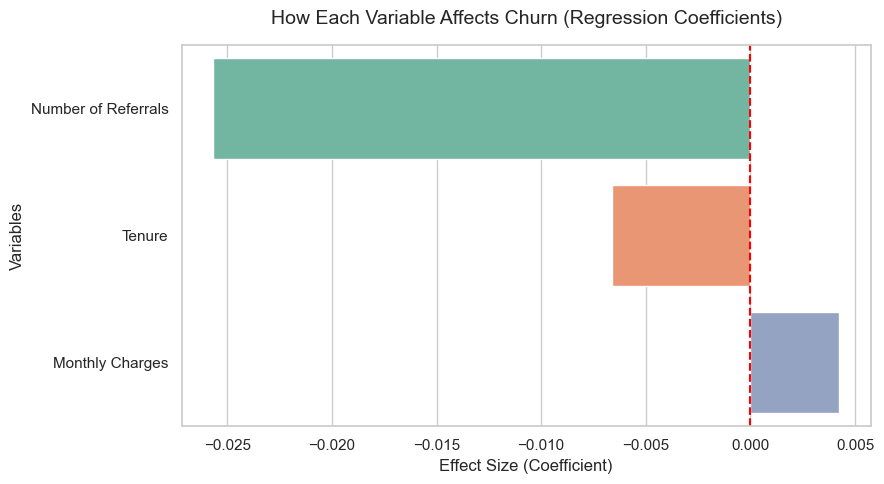

In [50]:
# 1. Extract coefficients (excluding the Intercept) and put them in a clean DataFrame
coef_df = pd.DataFrame({
    'Variable': ['Number of Referrals', 'Tenure', 'Monthly Charges'],
    'Coefficient': [model_multiple.params.iloc[1], model_multiple.params.iloc[2], model_multiple.params.iloc[3]]
})

# 2. Setup the chart size
plt.figure(figsize=(9, 5))

# 3. Plot the Coefficients Importance Chart
sns.barplot(x='Coefficient', y='Variable', data=coef_df, hue='Variable', palette='Set2', legend=False)

# 4. Add a dashed line at 0 to show positive vs negative impact clearly
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)

# 5. Customize titles and labels to look professional
plt.title("How Each Variable Affects Churn (Regression Coefficients)", fontsize=14, pad=15)
plt.xlabel("Effect Size (Coefficient)", fontsize=12)
plt.ylabel("Variables", fontsize=12)

# 6. Perfect layout spacing
plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(90deg, #0F766E, #2DD4BF);
    color: white;
    padding: 16px;
    border-radius: 12px;
    font-family: Arial;
    margin: 15px 0;
">
    <h2 style="margin: 0;">Correlation Analysis</h2>
    <p style="margin: 6px 0 0 0;">Analyze relationships between tenure, monthly charges, and referrals.</p>
</div>

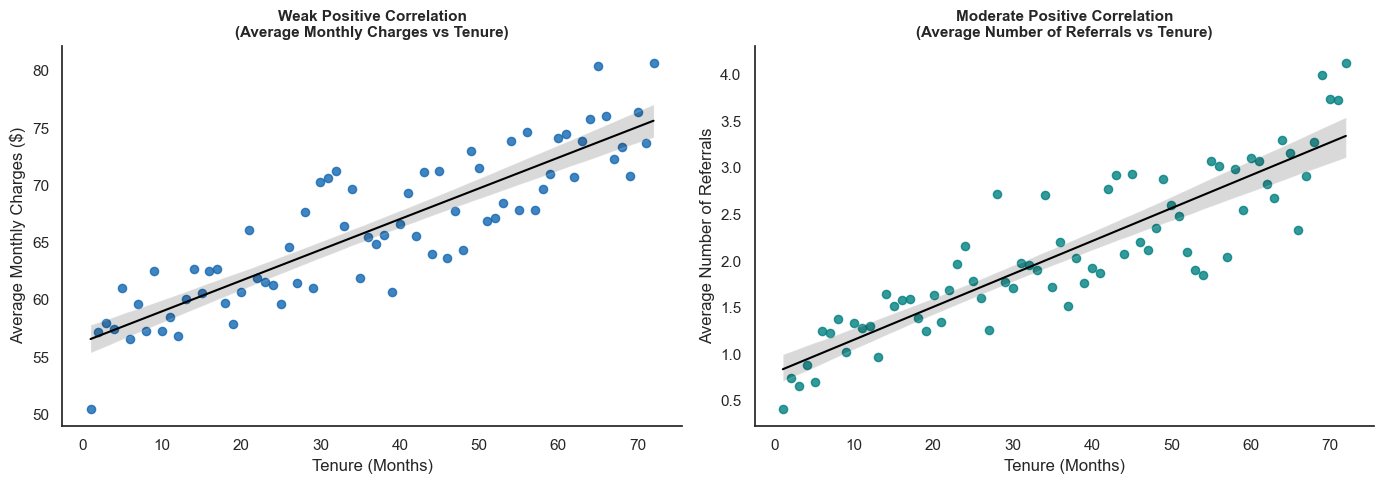

In [51]:
df = pd.read_excel('Fact_Telecom_Customers.xlsx')

df_grouped = df.groupby('tenure', as_index=False).agg({
    'monthly_charges': 'mean',
    'Number of Referrals': 'mean'
})

sns.set_style("white")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    x=df_grouped['tenure'], 
    y=df_grouped['monthly_charges'], 
    ax=axes[0],
    scatter_kws={'color': '#1167b1', 's': 35, 'alpha': 0.8},
    line_kws={'color': 'black', 'linewidth': 1.5}
)
axes[0].set_title('Weak Positive Correlation\n(Average Monthly Charges vs Tenure)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Average Monthly Charges ($)')

sns.regplot(
    x=df_grouped['tenure'], 
    y=df_grouped['Number of Referrals'], 
    ax=axes[1],
    scatter_kws={'color': '#008080', 's': 35, 'alpha': 0.8},
    line_kws={'color': 'black', 'linewidth': 1.5}
)
axes[1].set_title('Moderate Positive Correlation\n(Average Number of Referrals vs Tenure)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Tenure (Months)')
axes[1].set_ylabel('Average Number of Referrals')

sns.despine()

plt.tight_layout()
plt.show()